In [42]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "online_shoppers_intention.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "henrysue/online-shoppers-intention",
  file_path
)

Este cojunto de datos está formado por un total de 18 variables, donde 10 son numéricas y las otras 8 son categóricas. Una breve descripción de cada una a continuación:

## Column Descriptions:
- **`Administrative`:** Número de páginas de carácter administrativo (gestiones de la cuenta, configuración o información del usuario, etc) visitadas por el usuario.

- **`Administrative_Duration`:** Tiempo total que el usuario ha estado en páginas de este tipo.

- **`Informational`:** Número de páginas de carácter informativo (páginas sobre la empresa, quienes somos, términos y condiciones, etc) visitadas por el usuario.

- **`Informational_Duration`:** Tiempo total que el usuario ha estado en páginas de este tipo.

- **`ProductRelated`:** Número de páginas relacionadas con productos (catálogo, detalles de los productos, "carrito", etc) visitadas por el usuario.

- **`ProductRelated_Duration`:** Tiempo total que el usuario ha estado en páginas de este tipo.

- **`BounceRates`:** Porcentaje de robote. Este recoje el porcentaje de usuarios que entran a una página y salen sin realizar ninguna acción. Para este caso de sesión individual, representa si este usuario se ha movido por páginas con este porcentaje alto. A mayor valor, implica que el usuario ha navegado por páginas que históricamente no lograron retener la atención. Puede ser entendido como un indicador de Engagement.

- **`ExitRates`:** Porcentaje de salida. Este recoje el porcentaje de visitas a una pagina que fueron las últimas de la sesión. Para este caso de sesión individual, representa si este usuario se ha movido por páginas con este porcentaje alto. A mayor valor, implica que el usuario ha navegado por páginas que suelen implicar el fin de la navegación. Puede ser entendida como un indicador de proximidad al abandono.

- **`PageValues`:** Representa el valor económico medio de las páginas visitadas en la sesión, calculado sobre el histórico de transacciones del sitio. [Más información sobre su cálculo](https://support.google.com/analytics/answer/2695658?hl=en)

$$
PageValue= \frac{\text{Ingresos Totales} + \text{Valor total de objetos}}{\text{Número de visitas únicas a esa página}}
$$

- **`SpecialDay`:** Valor que indica la proximidad de la fecha de la sesión a un evento comercial imoprtante (p.e. Black Friday). Un valor de `1.0` significa que justamente esa sesión pertenece a un dia especial y `0.0` siginifica que no hay ningún evento importante cerca.

- **`Month`:** Mes en el cual se produno la sesión. Viene dado por una cadena *string*

- **`OperatingSystems`:** Valor entero (1-8) que indica el tipo de sistema operativo desde el cual el usuario está interactuando.

- **`Browser`:** Valor entero (1-12) que indica el navegador desde el cual el usuario está interactuando.

- **`Region`:** Valor entero (1-9) que indica la ubiación geográfica del usuario.

- **`TrafficType`:**  Valor entero (1-20) que indica la fuente de origen de la sesión. [Para más información sobre tipos de fuente de trafico clicka aquí](https://www.practicalecommerce.com/Understanding-Traffic-Sources-in-Google-Analytics)

- **`VisitorType`:** Variable categórica que indica si un usuario es nuevo (`New_Visitor`), uno que ya la ha visitado antes (`Returning_Visitor`) o otro caso (`Other`)

- **`Weekend`:** Valor booleano que indica si la sesión pertence a el fin de semana

- **`Revenue`:** Valor booleano que indica si la sesión finalizón con una transacción exitosa. Se traba de la variable **objetivo** a predecir.

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [45]:
uniques = df.nunique(axis=0)
print(uniques)

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64


In [46]:
# 3. Eliminar duplicados
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas encontradas: {duplicados}")
df = df.drop_duplicates()


Filas duplicadas encontradas: 125


In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12205 non-nul

Total de sesiones que finalizaron en compra: 1908
Total de sesiones que NO finalizaron en compra: 10297


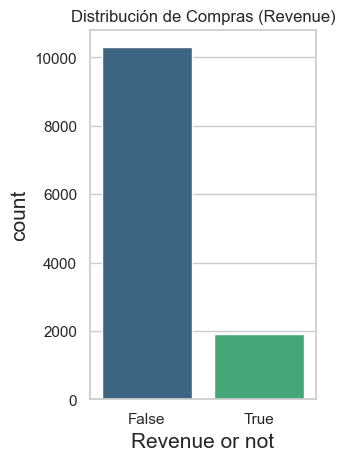

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

revenue = df['Revenue']
completed = revenue[revenue == True]
not_completed = revenue[revenue != True]

print(f'Total de sesiones que finalizaron en compra: {len(completed)}')
print(f'Total de sesiones que NO finalizaron en compra: {len(not_completed)}')

sns.set_theme(style="whitegrid")
plt.subplot(1, 2, 1)
sns.countplot(x='Revenue', hue='Revenue', data=df, legend=False, palette='viridis')
plt.title('Distribución de Compras (Revenue)')
plt.xlabel('Revenue or not', fontsize = 15)
plt.ylabel('count', fontsize = 15)
plt.show()

In [49]:
df['Month'].value_counts()

Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

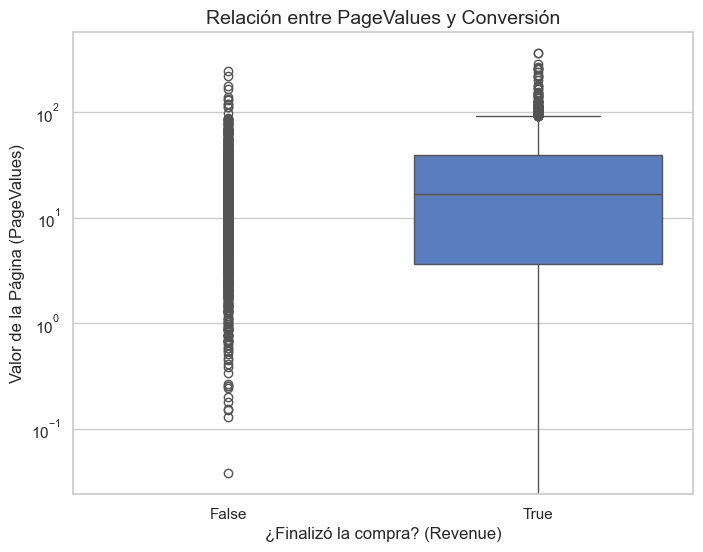

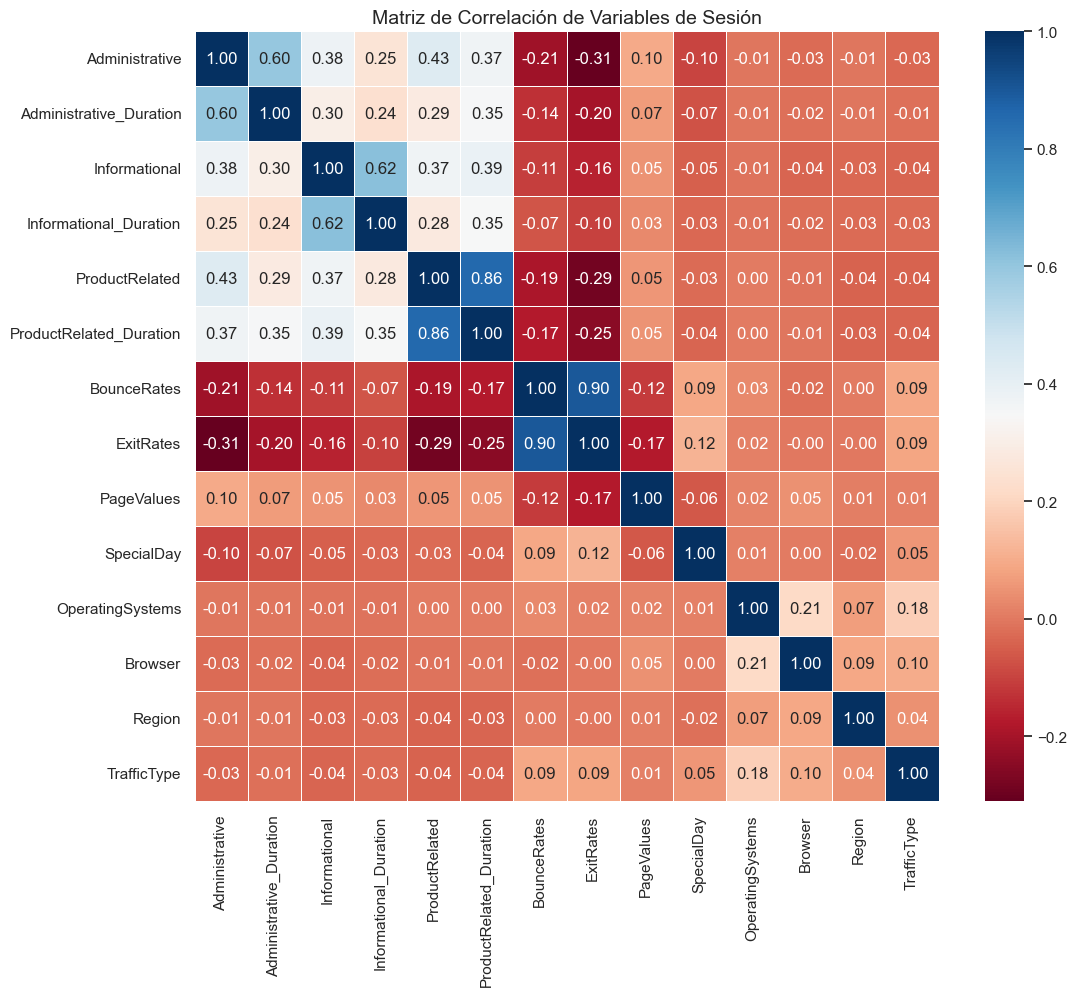

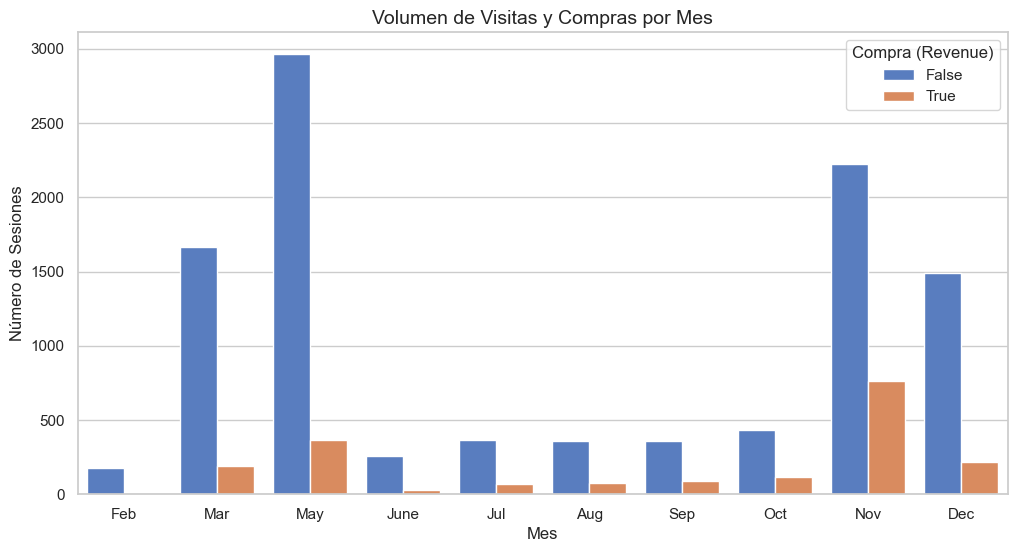

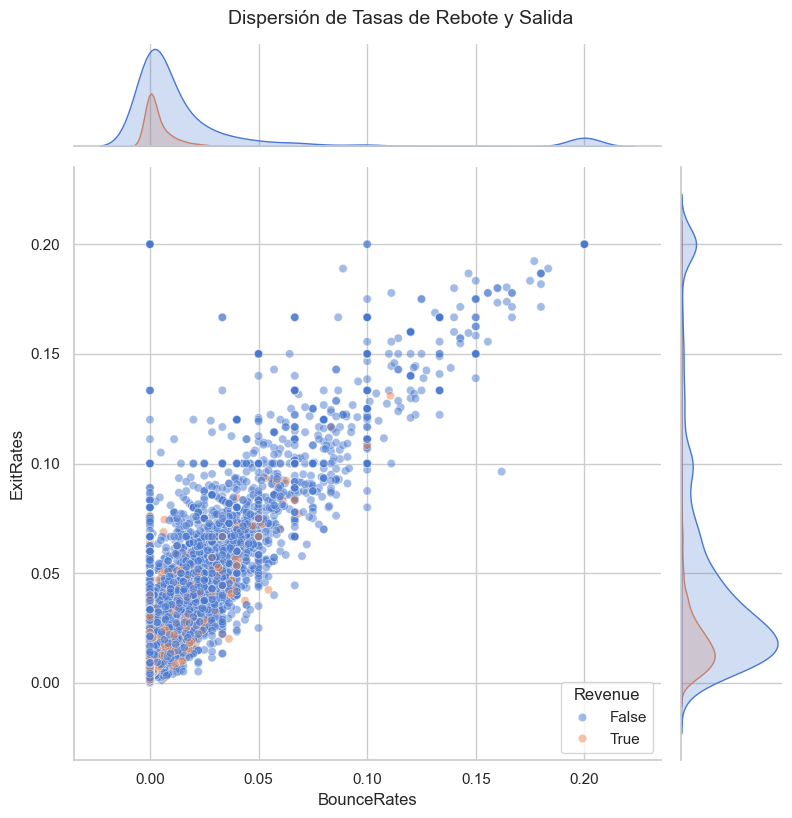

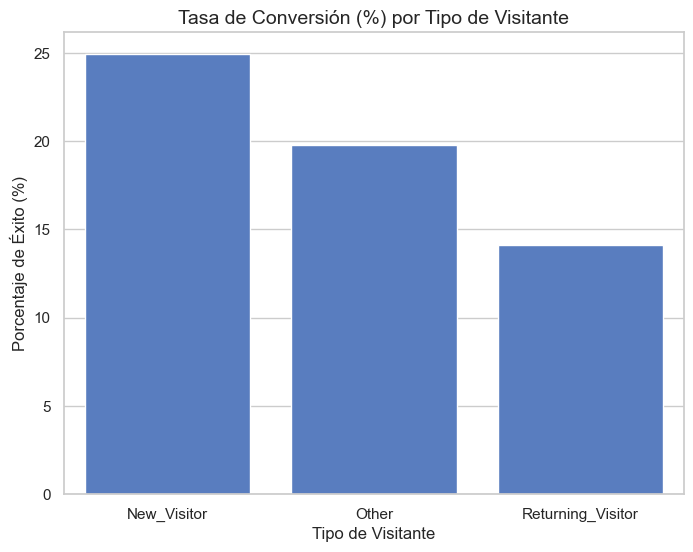

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo visual para que sea profesional
sns.set_theme(style="whitegrid", palette="muted")

# --- 1. BOXPLOT: PageValues vs Revenue (El Termómetro) ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('Relación entre PageValues y Conversión', fontsize=14)
plt.xlabel('¿Finalizó la compra? (Revenue)', fontsize=12)
plt.ylabel('Valor de la Página (PageValues)', fontsize=12)
plt.yscale('log') # Usamos escala logarítmica porque hay muchos ceros y valores altos
plt.show()

# --- 2. HEATMAP: Correlación de Variables (El Mapa de Calor) ---
plt.figure(figsize=(12, 10))
# Solo variables numéricas para la correlación
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables de Sesión', fontsize=14)
plt.show()

# --- 3. COUNTPLOT: Estacionalidad por Mes (El Funnel Temporal) ---
# Ordenamos los meses cronológicamente para que el gráfico tenga sentido
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', hue='Revenue', data=df, order=month_order)
plt.title('Volumen de Visitas y Compras por Mes', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Sesiones', fontsize=12)
plt.legend(title='Compra (Revenue)', loc='upper right')
plt.show()

# --- 4. JOINTPLOT: ExitRates vs BounceRates (Calidad de Navegación) ---
# Este gráfico combina dispersión con histogramas
g = sns.jointplot(x='BounceRates', y='ExitRates', data=df, hue='Revenue', 
                  kind='scatter', alpha=0.5, height=8)
g.fig.suptitle('Dispersión de Tasas de Rebote y Salida', y=1.02, fontsize=14)
plt.show()

# --- 5. BARPLOT: Conversión por Tipo de Visitante (Perfil de Cliente) ---
plt.figure(figsize=(8, 6))
# Calculamos el porcentaje de conversión por tipo de visitante para que sea más claro
conversion_rate = df.groupby('VisitorType')['Revenue'].mean() * 100
sns.barplot(x=conversion_rate.index, y=conversion_rate.values)
plt.title('Tasa de Conversión (%) por Tipo de Visitante', fontsize=14)
plt.ylabel('Porcentaje de Éxito (%)', fontsize=12)
plt.xlabel('Tipo de Visitante', fontsize=12)
plt.show()

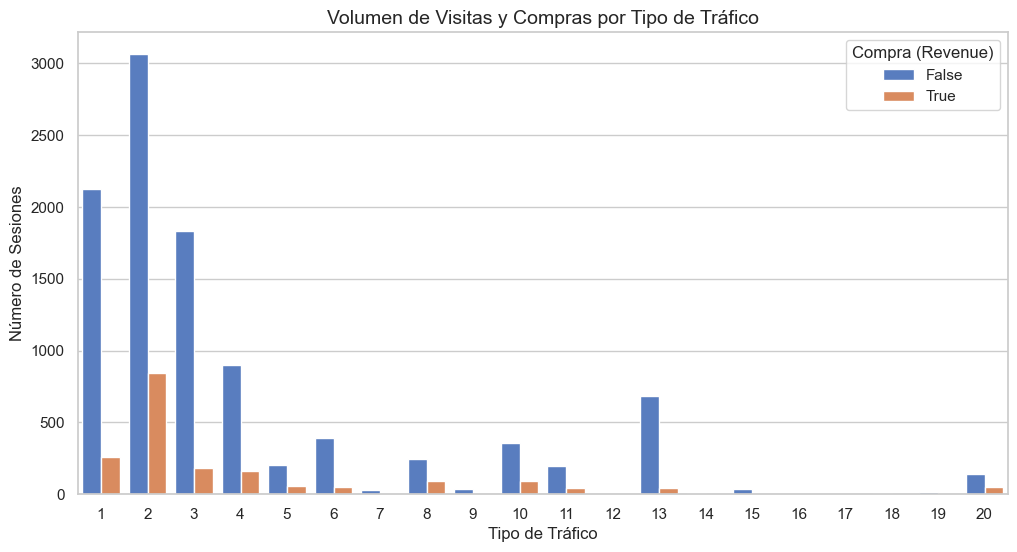

In [51]:
plt.figure(figsize=(12, 6))
sns.countplot(x='TrafficType', hue='Revenue', data=df)
plt.title('Volumen de Visitas y Compras por Tipo de Tráfico', fontsize=14)
plt.xlabel('Tipo de Tráfico', fontsize=12)
plt.ylabel('Número de Sesiones', fontsize=12)
plt.legend(title='Compra (Revenue)', loc='upper right')
plt.show()

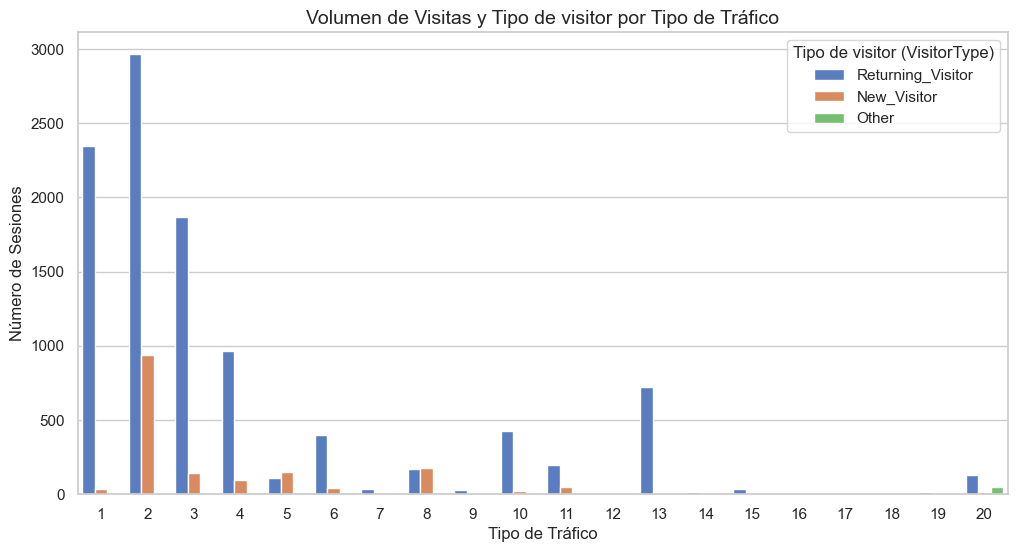

In [52]:
plt.figure(figsize=(12, 6))
sns.countplot(x='TrafficType', hue='VisitorType', data=df)
plt.title('Volumen de Visitas y Tipo de visitor por Tipo de Tráfico', fontsize=14)
plt.xlabel('Tipo de Tráfico', fontsize=12)
plt.ylabel('Número de Sesiones', fontsize=12)
plt.legend(title='Tipo de visitor (VisitorType)', loc='upper right')
plt.show()

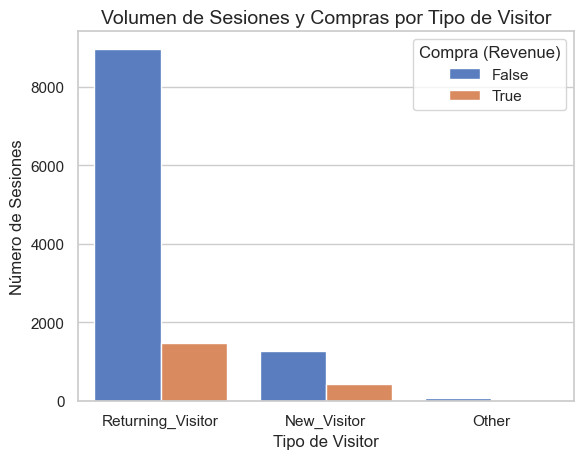

In [53]:
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title('Volumen de Sesiones y Compras por Tipo de Visitor', fontsize=14)
plt.xlabel('Tipo de Visitor', fontsize=12)
plt.ylabel('Número de Sesiones', fontsize=12)
plt.legend(title='Compra (Revenue)', loc='upper right')
plt.show()

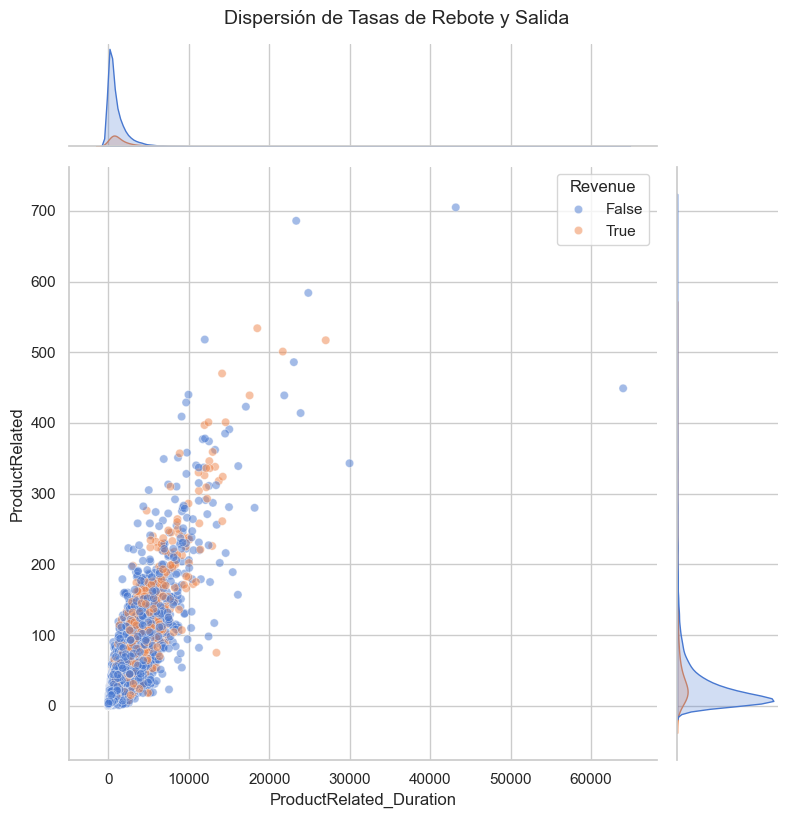

In [54]:
g = sns.jointplot(x='ProductRelated_Duration', y='ProductRelated', data=df, hue='Revenue', 
                  kind='scatter', alpha=0.5, height=8)
g.fig.suptitle('Dispersión de Tasas de Rebote y Salida', y=1.02, fontsize=14)
plt.show()

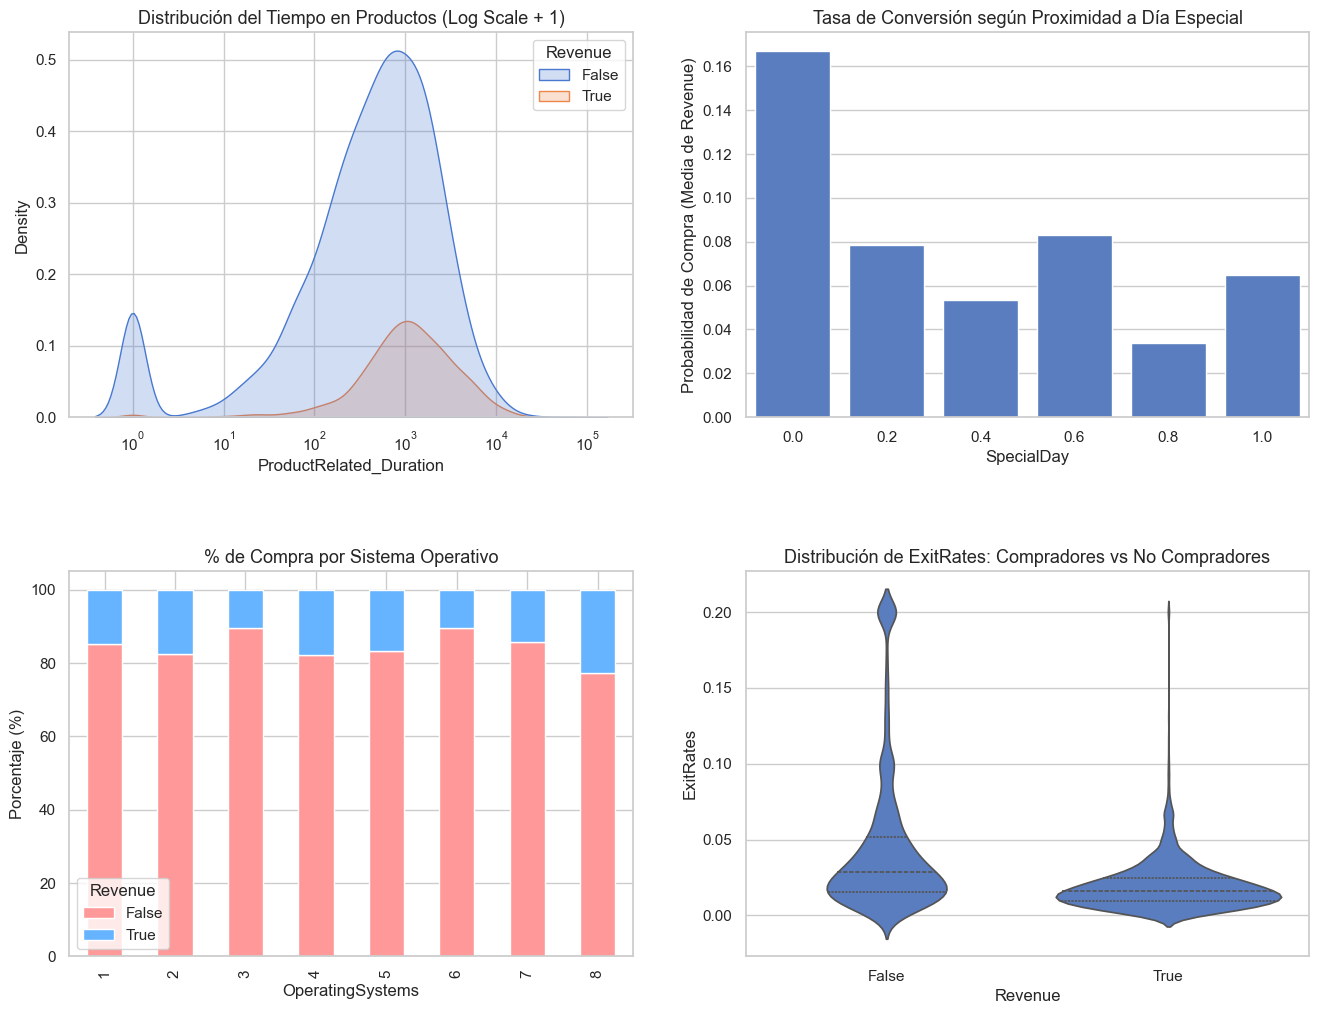

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos una figura con varios subplots para comparar
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# --- 1. ¿Cuánto tiempo real pasan en productos? (KDE Plot) ---
# Usamos escala logarítmica para ver mejor la distribución
sns.kdeplot(data=df, x=df['ProductRelated_Duration'] + 1, 
            hue='Revenue', fill=True, ax=axes[0,0], log_scale=True)
axes[0,0].set_title('Distribución del Tiempo en Productos (Log Scale + 1)', fontsize=13)

# --- 2. ¿Cómo afecta la cercanía a un Día Especial? ---
# Queremos ver si la gente compra más cuando falta poco para el evento (SpecialDay > 0)
sns.barplot(x='SpecialDay', y='Revenue', data=df, ax=axes[0,1], errorbar=None)
axes[0,1].set_title('Tasa de Conversión según Proximidad a Día Especial', fontsize=13)
axes[0,1].set_ylabel('Probabilidad de Compra (Media de Revenue)')

# --- 3. ¿Influye el sistema operativo en la decisión? ---
# Normalizamos para ver el porcentaje de éxito dentro de cada OS
os_revenue = pd.crosstab(df['OperatingSystems'], df['Revenue'], normalize='index') * 100
os_revenue.plot(kind='bar', stacked=True, ax=axes[1,0], color=['#ff9999','#66b3ff'])
axes[1,0].set_title('% de Compra por Sistema Operativo', fontsize=13)
axes[1,0].set_ylabel('Porcentaje (%)')

# --- 4. La diferencia en la Tasa de Salida (Violin Plot) ---
# El violin plot muestra la distribución y la mediana a la vez
sns.violinplot(x='Revenue', y='ExitRates', data=df, ax=axes[1,1], inner="quartile")
axes[1,1].set_title('Distribución de ExitRates: Compradores vs No Compradores', fontsize=13)

plt.show()

### **¿Que diriamos ante el por qué hemos decido mapear los datos anonimizados a valores reales?**

"Debido al carácter anonimizado de las variables categóricas (Browser, OS, TrafficType), se ha establecido una hipótesis de trabajo asignando etiquetas basadas en cuotas de mercado actuales y patrones de frecuencia detectados en el dataset. El objetivo de este mapeo no es la exactitud histórica de la fuente, sino dotar de realismo al flujo de Hiper-personalización, permitiendo validar cómo el sistema respondería ante perfiles de usuario reales (ej. iOS vs Android) en un entorno de producción."

In [60]:
import pandas as pd

# --- 1. DICCIONARIO: SISTEMAS OPERATIVOS ---
os_mapping = {
    1: 'iOS (Mobile)', 
    2: 'Windows (Desktop)', 
    3: 'Android (Mobile)', 
    4: 'macOS (Desktop)', 
    5: 'ChromeOS', 
    6: 'Linux', 
    7: 'Other Mobile', 
    8: 'Other/Legacy'
}

# --- 2. DICCIONARIO: NAVEGADORES ---
browser_mapping = {
    1: 'Safari', 
    2: 'Chrome', 
    3: 'Safari Mobile', 
    4: 'Firefox', 
    5: 'Edge', 
    6: 'Samsung Internet', 
    7: 'Android Webview', 
    8: 'Opera', 
    10: 'UC Browser', 
    13: 'Otros/In-App'
}

# --- 3. DICCIONARIO: REGIONES ---
# Basado en un modelo de expansión concéntrica (1 es el mercado principal)
region_mapping = {
    1: 'Nacional (Sede)', 
    2: 'Europa Norte', 
    3: 'Europa Sur', 
    4: 'Norteamérica', 
    5: 'Latam', 
    6: 'Asia-Pacífico', 
    7: 'EMEA (Oriente Medio)', 
    8: 'África', 
    9: 'Oceanía'
}

# --- 4. DICCIONARIO: TIPO DE TRÁFICO (Canales de Marketing) ---
traffic_mapping = {
    1: 'SEO (Google)', 
    2: 'Directo', 
    3: 'SEM (Google Ads)', 
    4: 'Social Ads', 
    5: 'Afiliados', 
    6: 'Email Marketing', 
    7: 'Referidos Blog', 
    8: 'Display Banner', 
    10: 'Campañas SMS', 
    11: 'Retargeting', 
    13: 'Push Notifications',
    20: 'Otros Canales'
}

# --- APLICACIÓN DE LOS MAPEOS ---
# Creamos columnas nuevas para el EDA sin borrar las numéricas
df['OS_Label'] = df['OperatingSystems'].map(os_mapping)
df['Browser_Label'] = df['Browser'].map(browser_mapping)
df['Region_Label'] = df['Region'].map(region_mapping)
df['Traffic_Label'] = df['TrafficType'].map(traffic_mapping)

# --- VERIFICACIÓN RÁPIDA ---
print("Ejemplo de las primeras filas con etiquetas:")
print(df[['OperatingSystems', 'OS_Label', 'TrafficType', 'Traffic_Label']].head(10))

Ejemplo de las primeras filas con etiquetas:
   OperatingSystems           OS_Label  TrafficType     Traffic_Label
0                 1       iOS (Mobile)            1      SEO (Google)
1                 2  Windows (Desktop)            2           Directo
2                 4    macOS (Desktop)            3  SEM (Google Ads)
3                 3   Android (Mobile)            4        Social Ads
4                 3   Android (Mobile)            4        Social Ads
5                 2  Windows (Desktop)            3  SEM (Google Ads)
6                 2  Windows (Desktop)            3  SEM (Google Ads)
7                 1       iOS (Mobile)            5         Afiliados
8                 2  Windows (Desktop)            3  SEM (Google Ads)
9                 2  Windows (Desktop)            2           Directo


<Axes: xlabel='OS_Label', ylabel='count'>

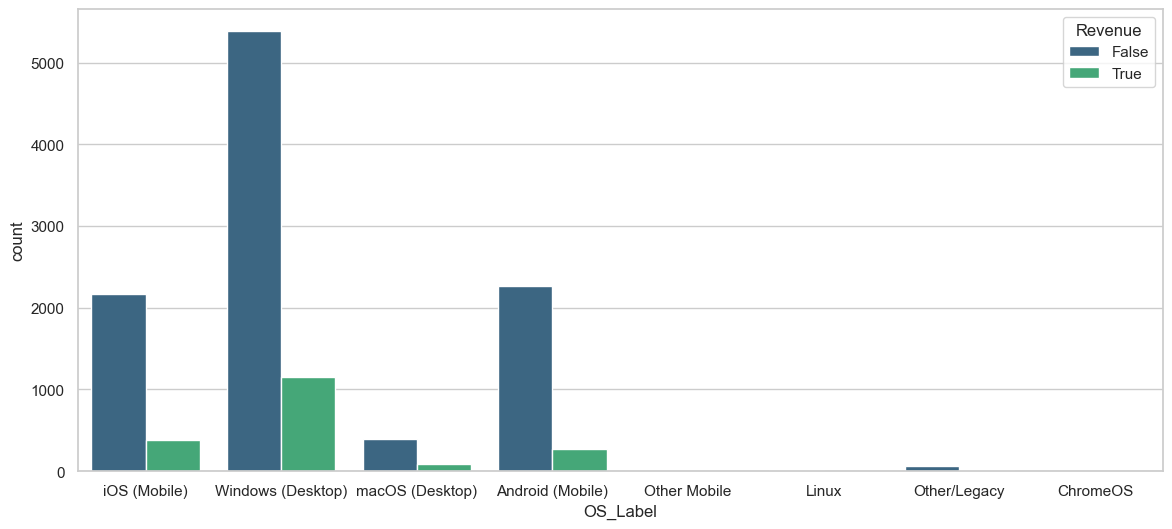

In [63]:
plt.figure(figsize=(14, 6))
sns.countplot(x='OS_Label', hue='Revenue', palette='viridis', data=df)

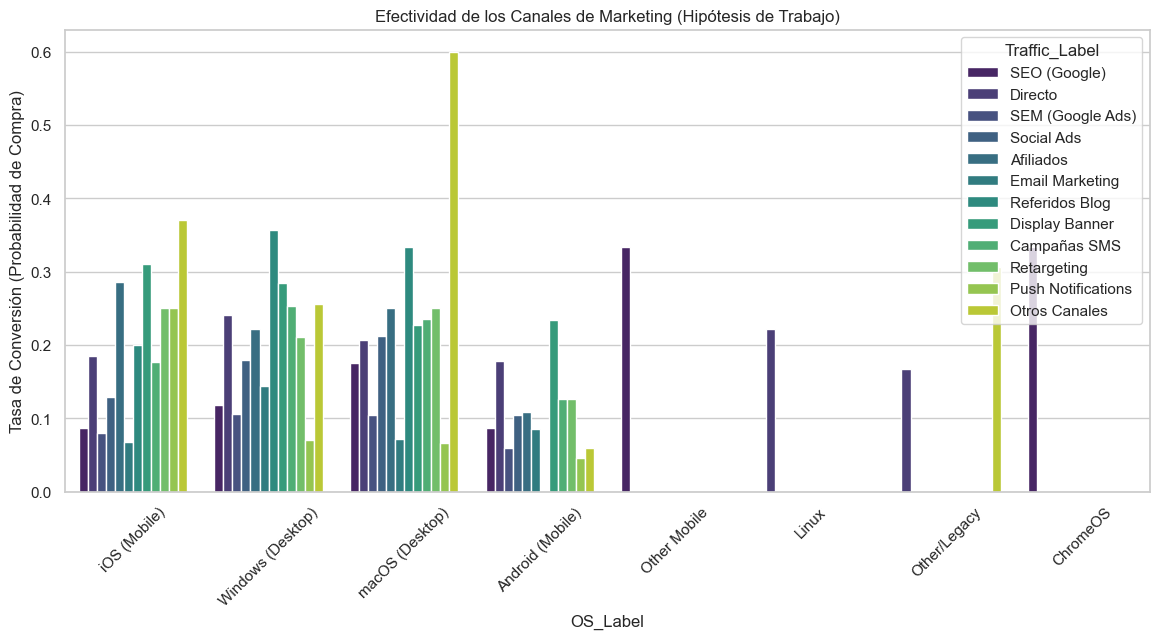

In [58]:
plt.figure(figsize=(14, 6))
# Calculamos el porcentaje de Revenue=True por cada canal
sns.barplot(data=df, x='OS_Label', y='Revenue', hue='Traffic_Label', palette='viridis', errorbar=None)
plt.xticks(rotation=45)
plt.title('Efectividad de los Canales de Marketing (Hipótesis de Trabajo)')
plt.ylabel('Tasa de Conversión (Probabilidad de Compra)')
plt.show()

In [59]:
df.info()

<class 'pandas.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12205 non-nul